# Notebook 03 — Feature Engineering
**Project:** Churn Prediction · Olist Brazilian E-Commerce  
**Input:** `data/processed/master.csv` + `data/processed/rfm_labeled.csv`  
**Output:** `data/processed/features.csv`

> **Konteks bisnis:** EDA menunjukkan recency adalah satu-satunya sinyal 
> linear yang kuat (korelasi 0.47). Notebook ini membangun fitur tambahan 
> yang memungkinkan model menangkap pola non-linear — kombinasi perilaku 
> customer yang tidak terlihat di heatmap.

---

## Tujuan
Mengubah data mentah menjadi **feature matrix siap modeling** — setiap baris 
merepresentasikan satu customer dengan fitur numerik yang bersih.

## Alur Kerja
1. Log-transform fitur RFM yang skewed
2. Aggregate data ke level `customer_unique_id`
3. Buat fitur derived yang punya business meaning
4. Encode variabel kategorikal
5. Handle missing values
6. Simpan feature matrix final

## Keputusan Desain Utama

| Keputusan | Pilihan | Alasan |
|---|---|---|
| Unit analisis | `customer_unique_id` | Target prediksi adalah customer, bukan order |
| Transformasi RFM | Log-transform | Distribusi sangat right-skewed (lihat EDA) |
| Missing values | Median imputation | Robust terhadap outlier yang tinggi di monetary |
| Encoding kategori | One-Hot Encoding | Kardinalitas rendah, tidak ada ordinal relationship |
| Kategori produk | Top 10 + `other` | Mencegah OHE menghasilkan terlalu banyak kolom sparse |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# Load data
df  = pd.read_csv("../data/processed/master.csv")
rfm = pd.read_csv("../data/processed/rfm_labeled.csv")

# Hanya convert kolom yang benar-benar dipakai di notebook ini
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print(f"Reference date: {df['order_purchase_timestamp'].max()}")
print(f"Master shape  : {df.shape}")
print(f"RFM shape     : {rfm.shape}")

Reference date: 2018-10-17 17:30:18
Master shape  : (113425, 23)
RFM shape     : (96096, 5)


## Log-Transform Fitur RFM

Dari EDA, distribusi `recency` dan `monetary` sangat **right-skewed**:
- `monetary`: std 640 jauh lebih besar dari mean 213 — ada outlier ekstrem hingga BRL 109k
- `recency`: range 0–772 hari dengan distribusi tidak merata

Transformasi `log1p` menekan outlier tanpa membuang datanya, 
sehingga model linear seperti Logistic Regression bisa bekerja lebih stabil.
Tree-based models (Random Forest, XGBoost) tidak wajib, tapi tetap membantu.

> `log1p` dipakai (bukan `log`) karena ada nilai 0 di recency dan monetary — 
> `log(0)` menghasilkan `-inf`.

In [ ]:
# RFM Features (sudah ada, tambahkan transformasi)
rfm['log_recency']   = np.log1p(rfm['recency'])
rfm['log_monetary']  = np.log1p(rfm['monetary'])
rfm['log_frequency'] = np.log1p(rfm['frequency'])
 
print("RFM + log-transform:")
print(rfm[['recency','log_recency','monetary','log_monetary']].describe().round(2))

RFM + log-transform:
        recency  log_recency   monetary  log_monetary
count  96096.00     96096.00   96096.00      96096.00
mean     287.74         5.50     213.02          4.81
std      153.41         0.62     640.92          0.91
min        0.00         0.00       0.00          0.00
25%      163.00         5.10      63.99          4.17
50%      268.00         5.59     113.15          4.74
75%      397.00         5.99     202.73          5.32
max      772.00         6.65  109312.64         11.60


## Hasil Log-Transform

Log-transform berhasil menekan range distribusi secara signifikan:

| Fitur | Sebelum (std) | Sesudah (std) | Sebelum (max) | Sesudah (max) |
|---|---|---|---|---|
| `recency` | 153.41 | 0.62 | 772 | 6.65 |
| `monetary` | 640.92 | 0.91 | 109,312 | 11.60 |

`monetary` yang tadinya punya std 640x lebih besar dari std log-nya (0.91) 
menunjukkan betapa ekstremnya skew sebelum transformasi — konfirmasi bahwa 
log-transform di sini bukan opsional, melainkan perlu.

> Nilai `min` = 0.00 pada kedua fitur mengkonfirmasi bahwa pilihan `log1p` 
> (bukan `log`) sudah tepat.

## Agregasi ke Level Customer

Master dataframe saat ini berisi **113,425 baris** — satu baris per item dalam order.  
Model churn membutuhkan **satu baris per customer**, sehingga semua fitur 
harus di-aggregate ke level `customer_unique_id`.

Fitur yang dibuat:

| Kategori | Fitur | Logika |
|---|---|---|
| Pembayaran | `avg_payment_value`, `total_payment_value` | Nilai transaksi customer |
| Pembayaran | `avg_installments`, `max_installments` | Kebiasaan cicilan |
| Harga | `avg_price`, `total_price`, `avg_freight` | Sensitifitas harga & ongkir |
| Review | `avg_review_score`, `min_review_score`, `review_count` | Kepuasan customer |
| Order | `total_items`, `total_orders` | Volume transaksi |
| Perilaku | `dominant_payment_type`, `dominant_category` | Preferensi dominan |

In [ ]:
# Customer-level Aggregation dari master.csv
customer_agg = df.groupby('customer_unique_id').agg(
 
    # Fitur pembayaran
    avg_payment_value     = ('payment_value',        'mean'),
    total_payment_value   = ('payment_value',        'sum'),
    avg_installments      = ('payment_installments', 'mean'),
    max_installments      = ('payment_installments', 'max'),
 
    # Fitur harga & ongkir
    avg_price             = ('price',                'mean'),
    total_price           = ('price',                'sum'),
    avg_freight           = ('freight_value',        'mean'),
 
    # Review
    avg_review_score      = ('review_score',         'mean'),
    min_review_score      = ('review_score',         'min'),
    review_count          = ('review_score',         'count'),
 
    # Order behaviour
    total_items           = ('order_item_id',        'sum'),
    total_orders          = ('order_id',             'nunique'),
 
    # Lokasi
    customer_state        = ('customer_state',       'first'),
 
    # Pembayaran dominan
    dominant_payment_type = ('payment_type',         lambda x: x.mode()[0] if not x.mode().empty else 'unknown'),
 
    # Kategori produk dominan
    dominant_category     = ('product_category_name_english',
                              lambda x: x.mode()[0] if not x.mode().empty else 'unknown'),
 
    # Tanggal untuk fitur temporal
    first_order_date      = ('order_purchase_timestamp', 'min'),
    last_order_date       = ('order_purchase_timestamp', 'max'),
 
).reset_index()
 
print(f"\nCustomer aggregation shape: {customer_agg.shape}")
print(customer_agg.head(3))


Customer aggregation shape: (96096, 18)
                 customer_unique_id  avg_payment_value  total_payment_value  \
0  0000366f3b9a7992bf8c76cfdf3221e2             141.90               141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f              27.19                27.19   
2  0000f46a3911fa3c0805444483337064              86.22                86.22   

   avg_installments  max_installments  avg_price  total_price  avg_freight  \
0               8.0               8.0      129.9        129.9        12.00   
1               1.0               1.0       18.9         18.9         8.29   
2               8.0               8.0       69.0         69.0        17.22   

   avg_review_score  min_review_score  review_count  total_items  \
0               5.0               5.0             1          1.0   
1               4.0               4.0             1          1.0   
2               3.0               3.0             1          1.0   

   total_orders customer_state dominant_payment_type dom

## Hasil Agregasi

96,096 unique customers berhasil di-aggregate dari 113,425 baris item.

Observasi dari sample data:
- **`avg_payment_value` = `total_payment_value`** di ketiga sample — karena 
  `total_orders = 1` pada ketiganya, average sama dengan total. Konsisten 
  dengan temuan EDA bahwa 96.9% customer adalah one-time buyer
- **`avg_installments` bervariasi** (1x vs 8x) — bisa jadi sinyal segmen customer 
  yang berbeda, menarik untuk dilihat korelasinya dengan churn
- **`dominant_category`** sudah terisi bersih tanpa NaN di sample — OHE di cell 6 
  tidak akan punya masalah pada baris ini
- **`first_order_date` = `last_order_date`** pada semua sample — sekali lagi 
  mengkonfirmasi one-time buyer mendominasi dataset

## Fitur Derived

Fitur buatan sendiri yang punya **business meaning** — menunjukkan domain 
understanding ke recruiter lebih dari sekadar aggregasi standar.

| Fitur | Formula | Interpretasi Bisnis |
|---|---|---|
| `customer_lifetime_days` | `last_order` - `first_order` | Seberapa lama customer aktif |
| `avg_order_value` | `monetary / frequency` | Nilai rata-rata per transaksi |
| `freight_ratio` | `avg_freight / avg_payment` | Seberapa besar porsi ongkir — proxy sensitivitas harga |
| `review_gap` | `avg_review - min_review` | Pernah kecewa atau tidak — konsistensi kepuasan |
| `first_order_month` | Bulan dari `first_order_date` | Apakah customer akuisisi di peak season |
| `first_order_dayofweek` | Hari dari `first_order_date` | Pola perilaku pembelian |

In [ ]:
# Fitur Temporal & Derived Features 
# Durasi jadi customer (hari dari order pertama ke terakhir)
customer_agg['customer_lifetime_days'] = (
    customer_agg['last_order_date'] - customer_agg['first_order_date']
).dt.days.fillna(0)
 
# Apakah customer pernah order di bulan Desember/November (peak season)?
# — fitur musiman sederhana
first_order = pd.to_datetime(customer_agg['first_order_date'])
customer_agg['first_order_month']    = first_order.dt.month
customer_agg['first_order_dayofweek']= first_order.dt.dayofweek  # 0=Senin
 
# Avg order value (monetary / frequency) — beda dari avg_payment_value
customer_agg['avg_order_value'] = (
    customer_agg['total_payment_value'] / customer_agg['total_orders']
)
 
# Freight ratio (ongkir / total bayar) — customer sensitif ongkir?
customer_agg['freight_ratio'] = (
    customer_agg['avg_freight'] / customer_agg['avg_payment_value'].replace(0, np.nan)
).fillna(0)
 
# Review consistency: selisih min & avg (semakin besar = pernah kecewa)
customer_agg['review_gap'] = customer_agg['avg_review_score'] - customer_agg['min_review_score']
 
print("\nFitur derived berhasil dibuat:")
new_cols = ['customer_lifetime_days', 'avg_order_value',
            'freight_ratio', 'review_gap', 'first_order_month']
print(customer_agg[new_cols].describe().round(2))


Fitur derived berhasil dibuat:
       customer_lifetime_days  avg_order_value  freight_ratio  review_gap  \
count                96096.00         96096.00       96096.00    95380.00   
mean                     2.71           205.45           0.19        0.01   
std                     25.39           617.77           0.12        0.12   
min                      0.00             0.00           0.00        0.00   
25%                      0.00            63.16           0.10        0.00   
50%                      0.00           110.60           0.17        0.00   
75%                      0.00           196.00           0.26        0.00   
max                    633.00        109312.64           0.96        3.76   

       first_order_month  
count           96096.00  
mean                6.03  
std                 3.23  
min                 1.00  
25%                 3.00  
50%                 6.00  
75%                 8.00  
max                12.00  


## Hasil Fitur Derived

Beberapa temuan menarik dari statistik di atas:

- **`customer_lifetime_days` median = 0** — konfirmasi kuat bahwa mayoritas customer 
  hanya order 1x sehingga first = last order date. Mean 2.71 hari ditarik oleh 
  sebagian kecil repeat buyer, max 633 hari
- **`avg_order_value` std (617) >> mean (205)** — distribusi sangat skewed, 
  perlu dipertimbangkan log-transform sebelum masuk model linear
- **`freight_ratio` rata-rata 0.19** — customer rata-rata membayar 19% dari 
  total transaksi untuk ongkir. Range 0–0.96 menunjukkan ada customer yang 
  hampir seluruh pembayarannya adalah ongkir
- **`review_gap` median = 0** — sebagian besar customer konsisten dalam rating, 
  hanya sedikit yang pernah memberikan review sangat berbeda antar order
- **`first_order_month`** terdistribusi merata (std 3.23, median bulan 6) — 
  tidak ada dominasi bulan tertentu, fitur ini mungkin sinyal lemah

In [6]:
# Merge semua fitur
features = rfm[['customer_unique_id', 'recency', 'frequency', 'monetary',
                 'log_recency', 'log_monetary', 'log_frequency',
                 'is_churned']].merge(
    customer_agg.drop(columns=['first_order_date', 'last_order_date']),
    on='customer_unique_id', how='left'
)
 
print(f"\nFeature matrix shape: {features.shape}")
print(f"Kolom: {features.columns.tolist()}")



Feature matrix shape: (96096, 29)
Kolom: ['customer_unique_id', 'recency', 'frequency', 'monetary', 'log_recency', 'log_monetary', 'log_frequency', 'is_churned', 'avg_payment_value', 'total_payment_value', 'avg_installments', 'max_installments', 'avg_price', 'total_price', 'avg_freight', 'avg_review_score', 'min_review_score', 'review_count', 'total_items', 'total_orders', 'customer_state', 'dominant_payment_type', 'dominant_category', 'customer_lifetime_days', 'first_order_month', 'first_order_dayofweek', 'avg_order_value', 'freight_ratio', 'review_gap']


## Encoding Variabel Kategorikal

Tiga kolom kategorikal perlu diubah ke numerik sebelum masuk model:

- **`customer_state`** (27 state) → One-Hot Encoding
- **`dominant_payment_type`** (5 tipe) → One-Hot Encoding  
- **`dominant_category`** (70+ kategori) → Top 10 + label `other`

Alasan OHE dipilih: tidak ada ordinal relationship antar kategori —  
state SP tidak "lebih besar" dari state RJ.

Alasan kategori produk di-cap top 10: 70+ kategori jika di-OHE penuh akan 
menghasilkan banyak kolom sparse yang menambah noise tanpa sinyal berarti.

In [ ]:
# Encode Kategorikal
# Top 10 kategori produk, sisanya 'other'
top_cats = features['dominant_category'].value_counts().head(10).index
features['dominant_category'] = features['dominant_category'].where(
    features['dominant_category'].isin(top_cats), 'other'
)
 
# OHE
features = pd.get_dummies(features,
    columns=['customer_state', 'dominant_payment_type', 'dominant_category'],
    drop_first=False,
    dtype=int
)
 
print(f"\nShape setelah OHE: {features.shape}")


Shape setelah OHE: (96096, 70)


## Hasil Encoding

Shape setelah OHE: **96,096 baris x 70 kolom**

Penambahan dari 29 kolom sebelum OHE menjadi 70 kolom:
- `customer_state` (27 unique state) → +27 kolom
- `dominant_payment_type` (6 tipe) → +6 kolom  
- `dominant_category` (top 10 + other) → +11 kolom

3 kolom kategorikal asli di-drop, digantikan 44 kolom OHE baru → net +41 kolom.
Tidak ada kolom sparse berlebihan karena kategori produk sudah di-cap top 10.

## Penanganan Missing Values

Strategi: **Median imputation** untuk semua kolom numerik.

Alasan median dipilih dibanding mean:
- `monetary` punya outlier ekstrem hingga BRL 109k — mean akan tertarik jauh ke atas
- Median lebih representatif untuk distribusi yang skewed
- Lebih aman dari mean karena tidak terpengaruh satu customer high-value

Missing rate keseluruhan dari EDA hanya **0.49%** — jumlahnya kecil,  
cukup di-fill tanpa perlu strategi kompleks seperti KNN imputation.

In [ ]:
# Handle Missing Values 
missing_before = features.isnull().sum().sum()
print(f"Missing sebelum: {missing_before}")
 
num_cols = features.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['is_churned']]
 
features[num_cols] = features[num_cols].fillna(features[num_cols].median())
 
missing_after = features.isnull().sum().sum()
print(f"Missing sesudah : {missing_after}")
print(f"✅ Semua missing handled dengan median imputation")

Missing sebelum: 3503
Missing sesudah : 0
✅ Semua missing handled dengan median imputation


## Hasil Missing Value Imputation

3,503 missing values berhasil di-fill dengan median imputation.

Sumber missing terbesar kemungkinan dari:
- `review_gap` — cell 4 menunjukkan count 95,380 (bukan 96,096), 
  berarti ada **716 customer tanpa review** sama sekali sehingga 
  `review_gap` tidak bisa dihitung
- Fitur turunan lain yang bergantung pada kolom dengan missing 
  di master.csv (0.49% dari EDA)

Setelah imputation: **0 missing values** — feature matrix bersih 
dan siap masuk modeling.


=== FINAL FEATURE MATRIX ===
Shape : (96096, 70)
Target distribution:
is_churned
1    0.899
0    0.101
Name: proportion, dtype: float64

Top 15 korelasi dengan is_churned:
is_churned                          1.000000
log_recency                         0.659883
recency                             0.471123
first_order_month                   0.164016
dominant_payment_type_debit_card    0.067426
customer_state_SP                   0.045759
avg_review_score                    0.043084
min_review_score                    0.041793
customer_lifetime_days              0.036643
dominant_category_housewares        0.035978
dominant_category_toys              0.027789
avg_freight                         0.025811
dominant_category_health_beauty     0.024852
dominant_category_auto              0.024775
avg_installments                    0.021541
Name: is_churned, dtype: float64


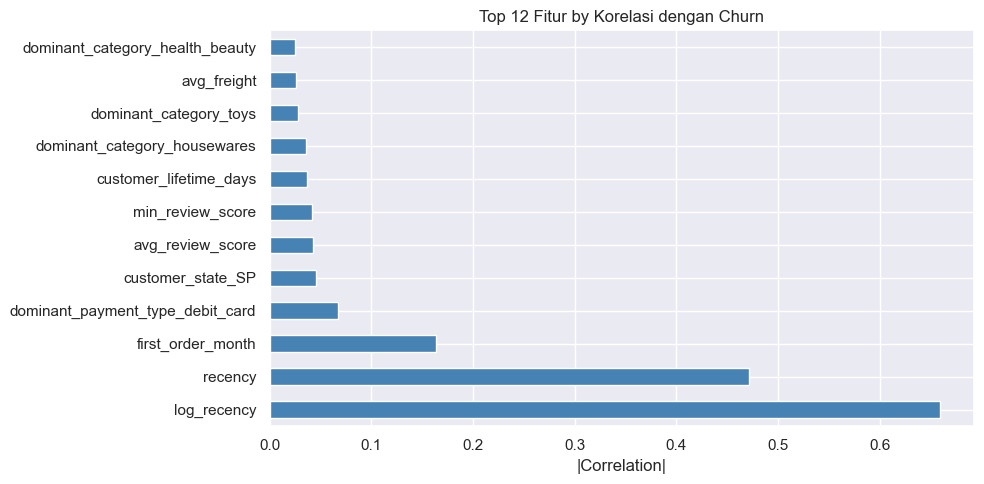


✅ features.csv disimpan ke data/processed/
Total fitur (termasuk target): 70


In [9]:
# Final Check & Save 
print("\n=== FINAL FEATURE MATRIX ===")
print(f"Shape : {features.shape}")
print(f"Target distribution:")
print(features['is_churned'].value_counts(normalize=True).round(3))
 
# Korelasi fitur utama dengan target
top_corr = features.select_dtypes(include=[np.number]).corr()['is_churned']\
                   .abs().sort_values(ascending=False).head(15)
print(f"\nTop 15 korelasi dengan is_churned:")
print(top_corr)
 
# Visualisasi top correlations
plt.figure(figsize=(10, 5))
top_corr.drop('is_churned').head(12).plot(kind='barh', color='steelblue')
plt.title('Top 12 Fitur by Korelasi dengan Churn')
plt.xlabel('|Correlation|')
plt.tight_layout()
plt.savefig('../data/processed/feature_correlation.png', dpi=150)
plt.show()
 
# Simpan
features.to_csv("../data/processed/features.csv", index=False)
print("\n✅ features.csv disimpan ke data/processed/")
print(f"Total fitur (termasuk target): {features.shape[1]}")

## Summary Notebook 03 — Feature Engineering

**Output:** `data/processed/features.csv`  
**Shape final:** 96,096 customers x 70 fitur  
**Target distribution:** Churn 89.9% | Non-churn 10.1%

**Fitur yang dibangun:**
- RFM + log-transform (6 fitur)
- Agregasi perilaku customer (12 fitur)
- Fitur derived bermakna bisnis (6 fitur)
- OHE state, payment type, kategori produk (+43 kolom)

**Temuan dari korelasi final:**
- `log_recency` (0.66) menggeser `recency` (0.47) sebagai fitur 
  paling berkorelasi — konfirmasi bahwa log-transform bukan hanya 
  normalisasi, tapi meningkatkan signal strength
- `first_order_month` (0.16) muncul sebagai kejutan di posisi 3 — 
  bulan akuisisi customer ternyata punya sinyal churn yang tidak 
  terlihat di EDA sebelumnya
- `dominant_payment_type_debit_card` (0.067) — customer debit card 
  cenderung lebih churn dibanding credit card, menarik untuk 
  divalidasi di feature importance model nanti

**Next:** Modeling di notebook `04_modeling.ipynb`  
→ Train/test split → Pipeline → Benchmark 3 model → Evaluasi ROC-AUC & F1